In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/processed/store_daily_sales.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Store", "Date"])

df.head()

,Store,Date,Sales
0,1,2013-01-02,5530
1,1,2013-01-03,4327
2,1,2013-01-04,4486
3,1,2013-01-05,4997
4,1,2013-01-07,7176


In [3]:
store_1 = df[df["Store"] == 1].copy()

store_1 = store_1.sort_values("Date")

store_1.head()

,Store,Date,Sales
0,1,2013-01-02,5530
1,1,2013-01-03,4327
2,1,2013-01-04,4486
3,1,2013-01-05,4997
4,1,2013-01-07,7176


In [4]:
print("Number of observations:", len(store_1))
print("Start date:", store_1["Date"].min())
print("End date:", store_1["Date"].max())

Number of observations: 781
Start date: 2013-01-02 00:00:00
End date: 2015-07-31 00:00:00


In [5]:
store_1 = store_1.set_index("Date")

sales = store_1["Sales"]

sales.head()


Date
2013-01-02    5530
2013-01-03    4327
2013-01-04    4486
2013-01-05    4997
2013-01-07    7176
Name: Sales, dtype: int64

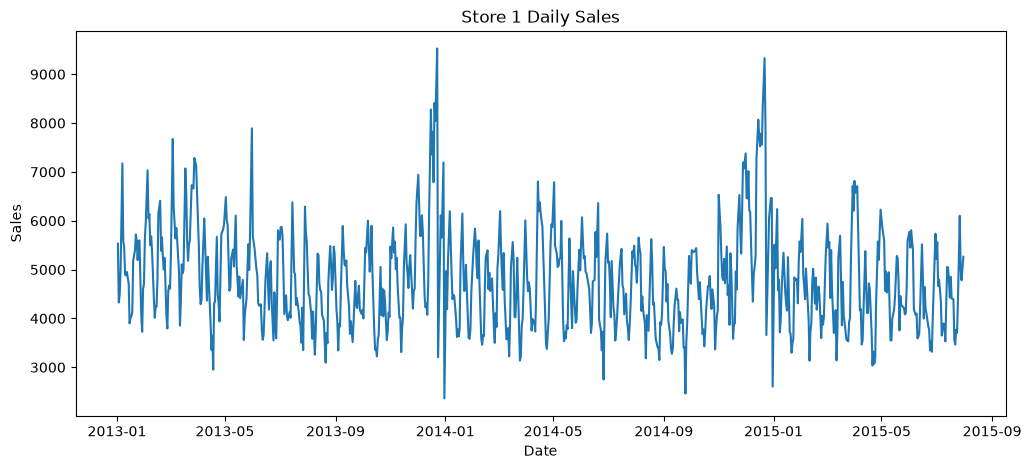

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(sales)

plt.title("Store 1 Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [7]:
train = sales.iloc[:-30]
test = sales.iloc[-30:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 751
Testing observations: 30


## SARIMA Model

SARIMA extends ARIMA by adding seasonal components.

For this project, a seasonal period of 7 days is used because the EDA showed weekday effects and the ARIMA residual diagnostics showed remaining autocorrelation at lag 7.

Initial candidate:

SARIMA(1,0,1)(1,0,1,7)

The model is evaluated on the same 30-day holdout used for ARIMA.

In [8]:
model = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = model.fit(disp=False)

print(sarima_model.summary())

C:\Users\Shrey\OneDrive\Desktop\stocksense\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\Shrey\OneDrive\Desktop\stocksense\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                  751
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -5996.601
Date:                           Thu, 08 Oct 2026   AIC                          12003.202
Time:                                   01:56:43   BIC                          12026.249
Sample:                                        0   HQIC                         12012.087
                                           - 751                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9944      0.004    255.644      0.000       0.987       1.002
ma.L1         -0.2557      0.031     -8.246

In [12]:
# Recreate train/test as simple sequential time-series values

train_values = pd.Series(train.values)
test_values = pd.Series(test.values)

print("Train:", len(train_values))
print("Test:", len(test_values))

Train: 751
Test: 30


In [13]:
model = SARIMAX(
    train_values,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = model.fit(disp=False)

print("SARIMA model fitted successfully!")

SARIMA model fitted successfully!


In [14]:
forecast = sarima_model.forecast(steps=30)

print("Forecast generated successfully!")
print(forecast[:10])

Forecast generated successfully!
751    3393.510472
752    3385.852405
753    3395.304695
754    3367.583139
755    3423.487260
756    3384.244384
757    3387.237285
758    3359.728608
759    3340.356170
760    3320.026757
Name: predicted_mean, dtype: float64
